In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/merged_gw.csv')
df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_in,transfers_out,value,was_home,yellow_cards,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles,GW
0,Reinildo Mandava,DEF,Sunderland,0.5,0,0,27,1,2.5,541,...,0,0,40,True,0,6,8,3,2,1
1,Lewis Dobbin,MID,Aston Villa,1.0,0,0,0,0,0.0,57,...,0,0,50,True,0,0,0,0,0,1
2,Ryan Christie,MID,Bournemouth,0.0,0,0,0,0,0.0,87,...,0,0,50,False,0,0,0,0,0,1
3,Zeki Amdouni,FWD,Burnley,0.0,0,0,0,0,0.0,216,...,0,0,50,False,0,0,0,0,0,1
4,Lucas Tolentino Coelho de Lima,MID,West Ham,2.6,0,0,11,0,14.2,612,...,0,0,60,False,0,0,6,5,1,1


In [3]:
season_totals = df.groupby('name')['total_points'].sum().sort_values(ascending=False)
top15 = season_totals.head(15)
top15

name
Erling Haaland                      239
Bruno Borges Fernandes              235
Gabriel dos Santos Magalhães        209
Antoine Semenyo                     202
Morgan Gibbs-White                  188
Jarrod Bowen                        187
Declan Rice                         184
Igor Thiago Nascimento Rodrigues    181
Elliot Anderson                     180
Marc Guéhi                          179
João Pedro Junqueira de Jesus       177
Virgil van Dijk                     175
Marcos Senesi Barón                 175
James Tarkowski                     170
Morgan Rogers                       169
Name: total_points, dtype: int64

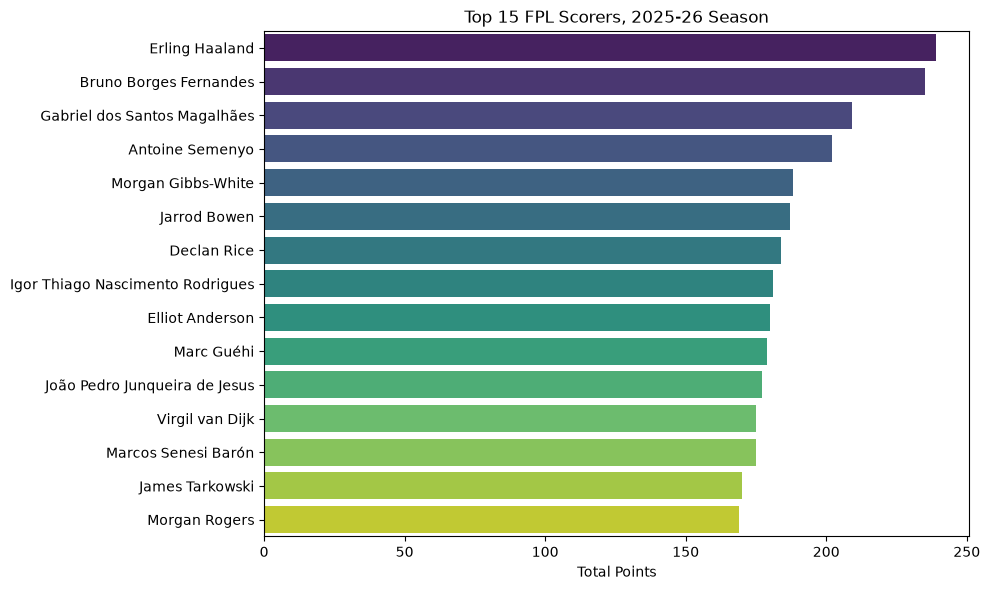

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette='viridis', legend=False)
plt.xlabel('Total Points')
plt.ylabel('')
plt.title('Top 15 FPL Scorers, 2025-26 Season')
plt.tight_layout()
plt.savefig('../charts/top15_scorers.png', dpi=150)
plt.show()

In [6]:
print(list(df.columns))

['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'modified', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles', 'GW']


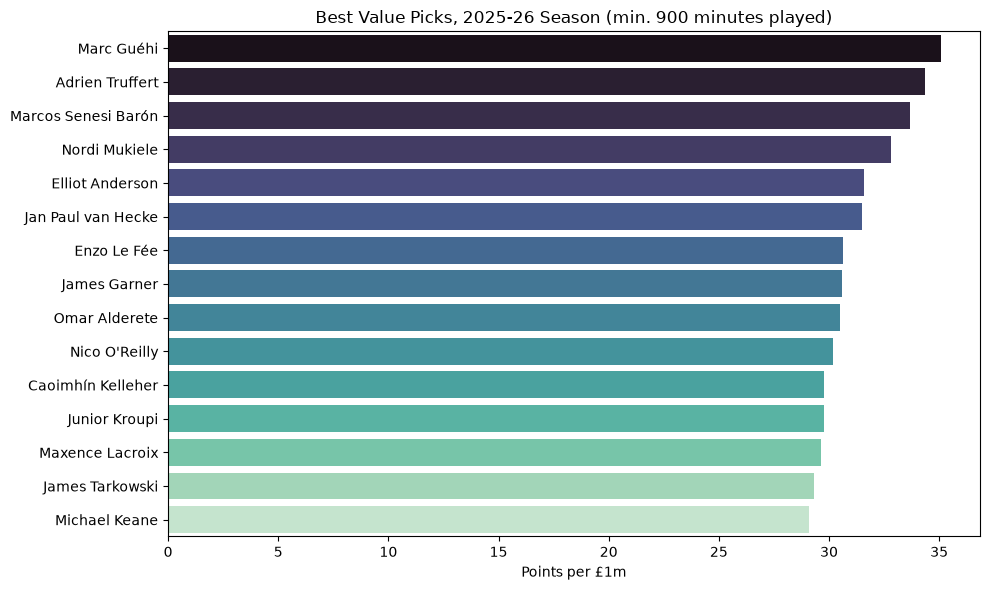

In [7]:
# Get each player's final price (last gameweek they appeared)
latest_price = df.sort_values('GW').groupby('name')['value'].last() / 10
season_totals_df = season_totals.reset_index()
season_totals_df.columns = ['name', 'total_points']
season_totals_df['price'] = season_totals_df['name'].map(latest_price)
season_totals_df['points_per_million'] = season_totals_df['total_points'] / season_totals_df['price']

# Filter to players who actually played meaningful minutes across the season
minutes_played = df.groupby('name')['minutes'].sum()
season_totals_df['minutes'] = season_totals_df['name'].map(minutes_played)
value_picks = season_totals_df[season_totals_df['minutes'] > 900].sort_values('points_per_million', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='points_per_million', y='name', data=value_picks, hue='name', palette='mako', legend=False)
plt.xlabel('Points per £1m')
plt.ylabel('')
plt.title('Best Value Picks, 2025-26 Season (min. 900 minutes played)')
plt.tight_layout()
plt.savefig('../charts/value_picks.png', dpi=150)
plt.show()

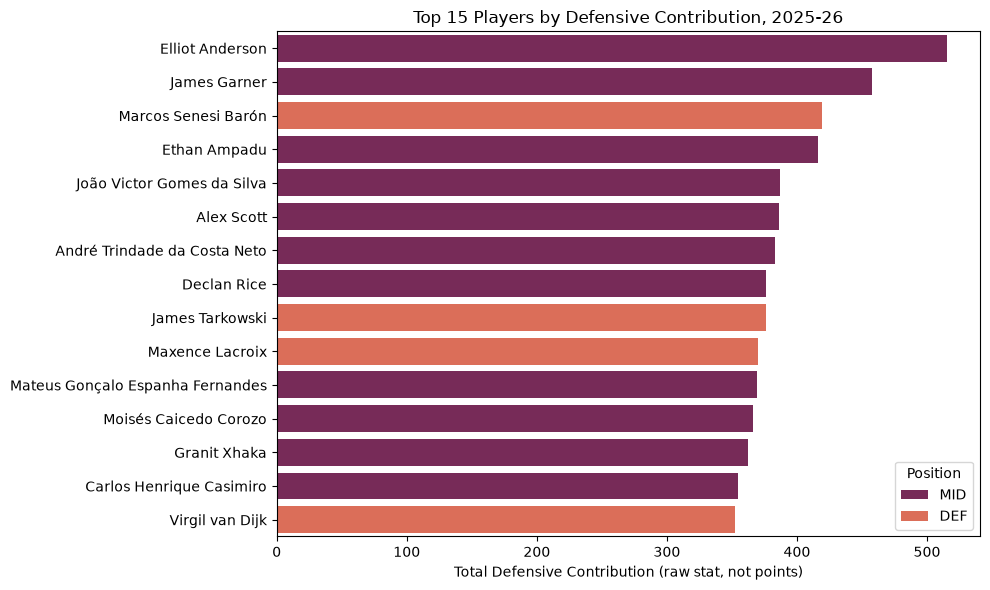

In [8]:
defcon_totals = df.groupby(['name', 'position'])['defensive_contribution'].sum().reset_index()
defcon_totals = defcon_totals.sort_values('defensive_contribution', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='defensive_contribution', y='name', data=defcon_totals, hue='position', dodge=False, palette='rocket')
plt.xlabel('Total Defensive Contribution (raw stat, not points)')
plt.ylabel('')
plt.title('Top 15 Players by Defensive Contribution, 2025-26')
plt.legend(title='Position')
plt.tight_layout()
plt.savefig('../charts/defcon_leaders.png', dpi=150)
plt.show()

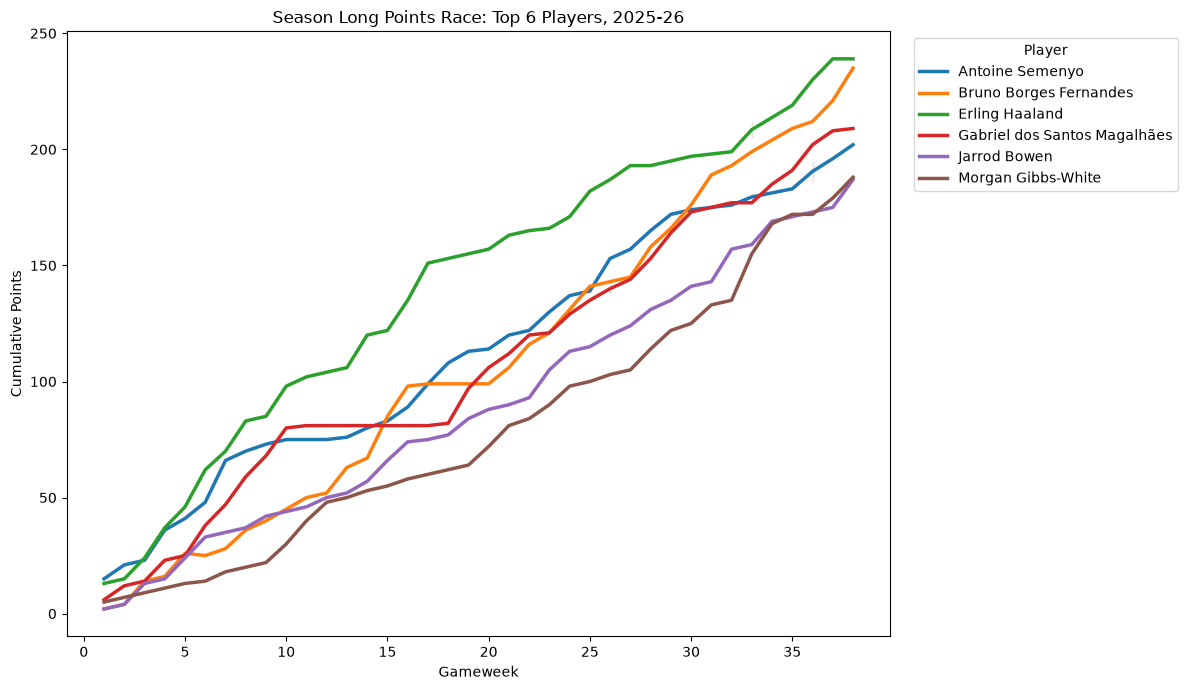

In [9]:
top6_names = season_totals.head(6).index.tolist()
momentum_df = df[df['name'].isin(top6_names)].copy()
momentum_df = momentum_df.sort_values(['name', 'GW'])
momentum_df['cumulative_points'] = momentum_df.groupby('name')['total_points'].cumsum()

plt.figure(figsize=(12, 7))
sns.lineplot(data=momentum_df, x='GW', y='cumulative_points', hue='name', linewidth=2.5)
plt.xlabel('Gameweek')
plt.ylabel('Cumulative Points')
plt.title('Season Long Points Race: Top 6 Players, 2025-26')
plt.legend(title='Player', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../charts/season_momentum.png', dpi=150)
plt.show()

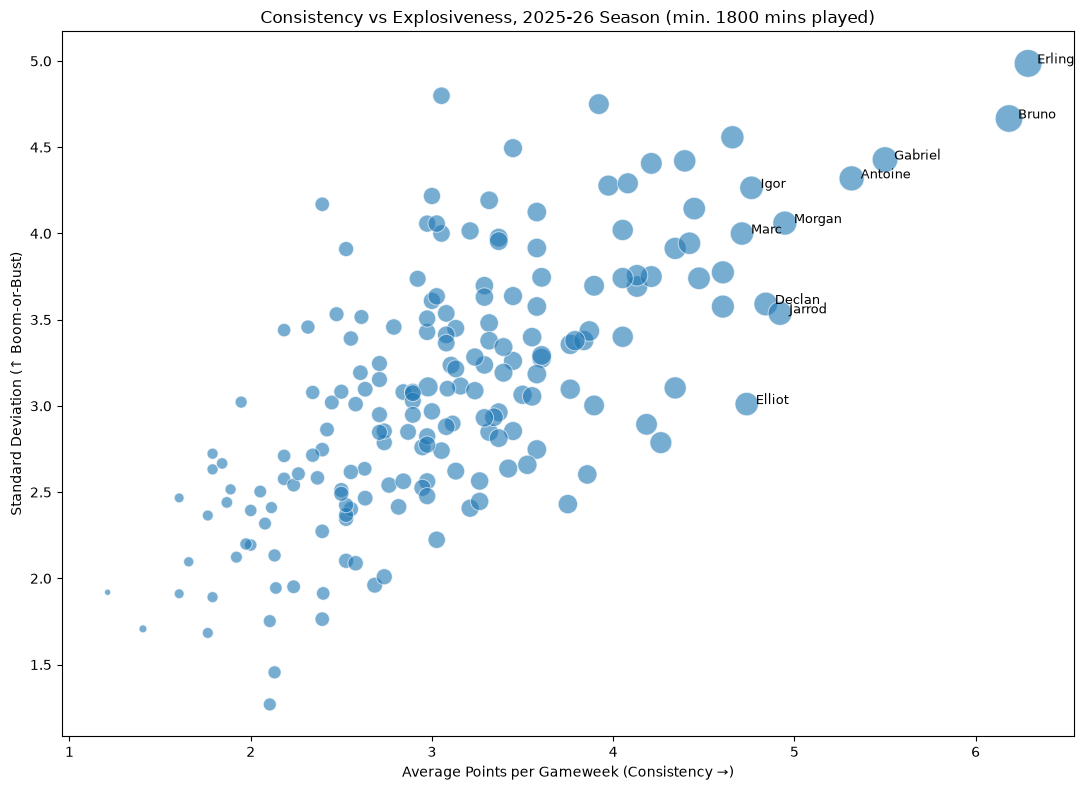

In [10]:
player_stats = df.groupby('name').agg(
    avg_points=('total_points', 'mean'),
    std_points=('total_points', 'std'),
    total=('total_points', 'sum'),
    minutes=('minutes', 'sum')
).reset_index()

# Keep only regular starters for a meaningful comparison
regulars = player_stats[player_stats['minutes'] > 1800]

plt.figure(figsize=(11, 8))
sns.scatterplot(data=regulars, x='avg_points', y='std_points', size='total', sizes=(20, 400), alpha=0.6, legend=False)

# Label a handful of standout names
standouts = regulars.sort_values('total', ascending=False).head(10)
for _, row in standouts.iterrows():
    plt.text(row['avg_points']+0.05, row['std_points'], row['name'].split()[0], fontsize=9)

plt.xlabel('Average Points per Gameweek (Consistency →)')
plt.ylabel('Standard Deviation (↑ Boom-or-Bust)')
plt.title('Consistency vs Explosiveness, 2025-26 Season (min. 1800 mins played)')
plt.tight_layout()
plt.savefig('../charts/consistency_vs_explosiveness.png', dpi=150)
plt.show()